# Autoencoder Compression Quality Diagnostics

Visualisation notebook for the `DenoisingAutoencoder` — analogous to `visualise_rom.ipynb`.

**Contents:**
1. Load trained autoencoder & dataset
2. Original waveform vs reconstruction (from noisy data)
3. Distribution of relative errors with summary statistics
4. Eigenvalues of the covariance matrix (data, waveform, bottleneck)
5. Distance-vs-distance scatter plots
6. Sensitivity to single-parameter variation (fix one, vary the other)

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import h5py

from pembhb import ROOT_DIR
from pembhb.data import MBHBDataModule
from pembhb.autoencoder import DenoisingAutoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

ROOT_DIR: /u/g/gpuleo/pembhb
Using device: cuda


## 1 — Configuration & loading

In [5]:
# ── paths ─────────────────────────────────────────────────────────────────
# Point these to your trained checkpoint and the dataset it was trained on.
import glob


ckpt_path = glob.glob("/data/gpuleo/mbhb/logs/autoencoder/version_1/checkpoints/*.ckpt")[0]  # <-- fill in: path to the .ckpt file
data_filename = "/data/gpuleo/mbhb/20260212fullsky_narrowmc_tc_v0/simulation_round_1.h5"
# Datasets where one parameter is fixed and the other varies
fix_q_filename  = "miao"
fix_mc_filename = "bau"

# Output directory for plots
ae_basename = os.path.basename(ckpt_path).removesuffix('.ckpt')
plot_dir = os.path.join(ROOT_DIR, "plots", f"diagnose_ae_{ae_basename}")
os.makedirs(plot_dir, exist_ok=True)
print(f"Plots → {plot_dir}")

Plots → /u/g/gpuleo/pembhb/plots/diagnose_ae_ae-epoch=297-val_loss=1.3846e-04


In [6]:
# ── load autoencoder from checkpoint ──────────────────────────────────────
ae = DenoisingAutoencoder.load_from_checkpoint(ckpt_path, map_location=device)
ae = ae.to(device)
ae.eval()
print(f"Loaded autoencoder  representation={ae.representation}  "
      f"n_channels={ae.n_channels}  n_freqs={ae.n_freqs}  "
      f"sizes={ae.sizes}")
print(f"Normalisation fitted: global_scale={ae.global_scale_factor.item():.4e}")

Loaded autoencoder  representation=real_imag  n_channels=2  n_freqs=4096  sizes=(16, 32, 64, 128, 256)
Normalisation fitted: global_scale=1.5628e-17


In [7]:
# ── load data ─────────────────────────────────────────────────────────────
batch_size = 400
datamodule = MBHBDataModule(data_filename, batch_size=batch_size,
                            num_workers=2, cache_in_memory=False)
datamodule.setup(stage="fit")
dataloader = datamodule.train_dataloader(shuffle=False)

with h5py.File(data_filename, 'r') as f:
    freqs = f["frequencies"][()]
print(f"Dataset loaded: {len(datamodule.full_dataset)} samples, {len(freqs)} freq bins")

Dataset loaded: 50000 samples, 4096 freq bins


## 2 — Run autoencoder on data: collect reconstructions & bottlenecks

In [8]:
# Collect reconstructions, bottlenecks, originals over several batches
N_batches_eval = 5  # how many batches to evaluate

all_wave_fd = []
all_data_fd = []
all_rec_norm = []      # reconstructed (normalised space)
all_clean_norm = []    # clean target (normalised space)
all_bottleneck = []    # flattened bottleneck
all_params = []

with torch.no_grad():
    for ii, batch in enumerate(dataloader):
        if ii >= N_batches_eval:
            break
        wave_fd = batch["wave_fd"].to(device)
        noise_fd = batch["noise_fd"].to(device)
        data_fd = wave_fd + noise_fd
        params = batch["source_parameters"][:, :2]  # (B, 2): logMc, q

        # Preprocess (complex → real → normalise)
        noisy_norm = ae.preprocess(data_fd)
        clean_norm = ae.preprocess(wave_fd)

        # Encode → bottleneck + skips
        bottleneck, skips = ae.encode(noisy_norm)
        print(bottleneck.shape)
        
        # Decode → reconstruction in normalised space
        rec_norm = ae.decode(bottleneck, skips)

        all_wave_fd.append(wave_fd.cpu())
        all_data_fd.append(data_fd.cpu())
        all_rec_norm.append(rec_norm.cpu())
        all_clean_norm.append(clean_norm.cpu())
        all_bottleneck.append(bottleneck.reshape(bottleneck.shape[0], -1).cpu())
        all_params.append(params.cpu())


wave_fd     = torch.cat(all_wave_fd)
data_fd     = torch.cat(all_data_fd)
rec_norm    = torch.cat(all_rec_norm)
clean_norm  = torch.cat(all_clean_norm)
bottleneck  = torch.cat(all_bottleneck)
params      = torch.cat(all_params)

# Denormalise reconstruction back to the real representation space
rec_real  = ae._denormalize(rec_norm.to(device)).cpu()
clean_real = ae._denormalize(clean_norm.to(device)).cpu()

n_samples = wave_fd.shape[0]
n_ch = ae.n_channels
print(f"Evaluated {n_samples} samples")
print(f"Bottleneck shape concatenated : {bottleneck.shape} features")

torch.Size([400, 256, 2])
torch.Size([400, 256, 2])
torch.Size([400, 256, 2])
torch.Size([400, 256, 2])
torch.Size([400, 256, 2])
Evaluated 2000 samples
Bottleneck shape concatenated : torch.Size([2000, 512]) features


In [9]:
all_bottleneck[0].shape

torch.Size([400, 512])

## 3 — Original waveform vs reconstruction

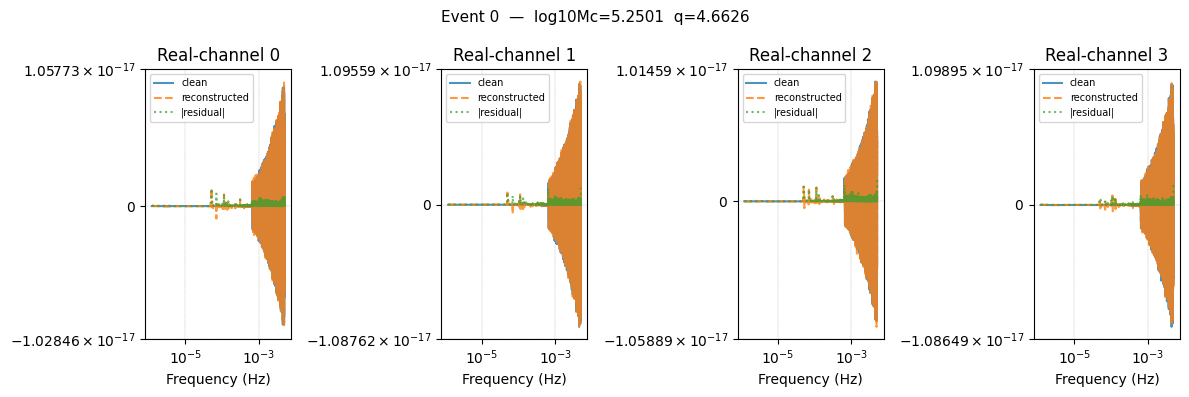

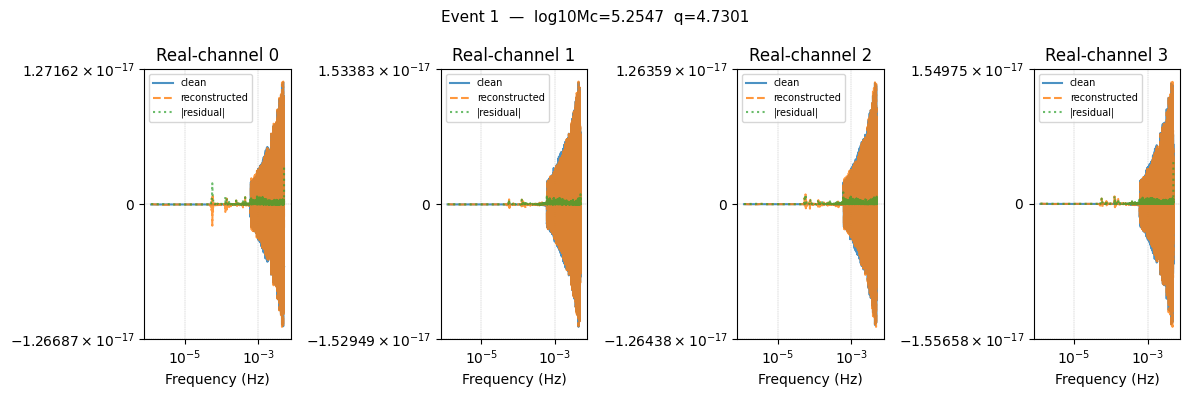

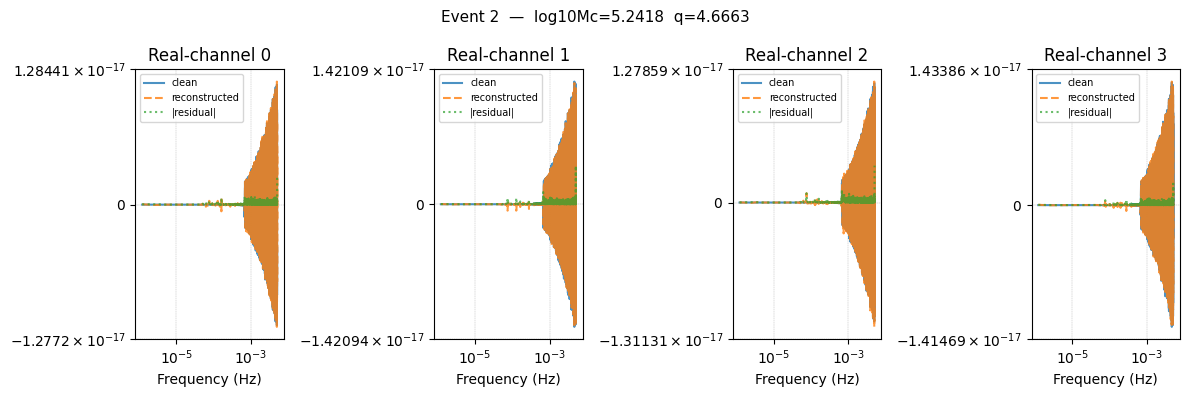

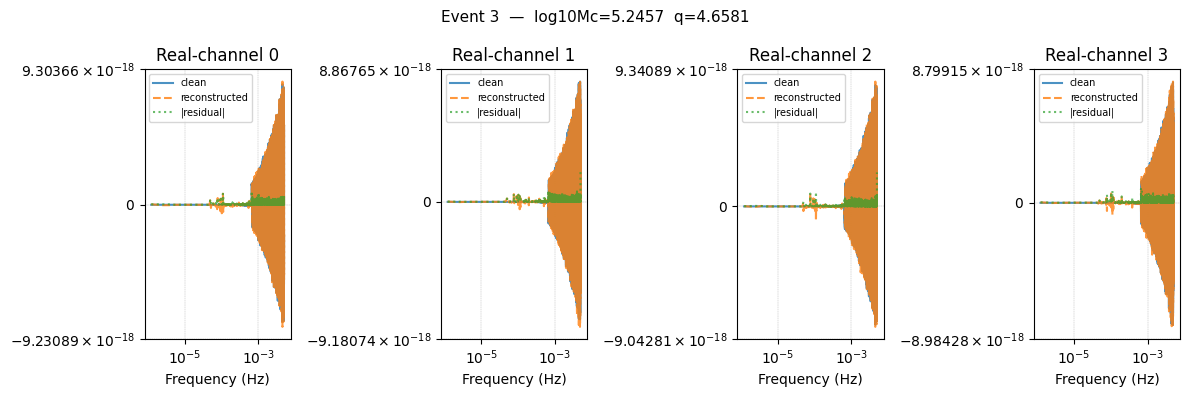

In [10]:
N_events_plot = 4

# We compare in the *real representation* space (the space the AE operates in)
for j in range(N_events_plot):
    fig, axes = plt.subplots(1, 2 * n_ch, figsize=(6 * n_ch, 4))
    if 2 * n_ch == 1:
        axes = [axes]
    for c in range(2 * n_ch):
        ax = axes[c]
        orig = clean_real[j, c, :].numpy()
        recon = rec_real[j, c, :].numpy()
        residual = np.abs(orig - recon)

        ax.plot(freqs, orig, label="clean", alpha=0.8)
        ax.plot(freqs, recon, '--', label="reconstructed", alpha=0.8)
        ax.plot(freqs, residual, ':', label="|residual|", alpha=0.7)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1e-6)
        ax.set_title(f"Real-channel {c}")
        ax.legend(fontsize=7)
        ax.grid(True, which='both', ls='--', lw=0.3)

    p = params[j].numpy()
    fig.suptitle(f"Event {j}  —  log10Mc={p[0]:.4f}  q={p[1]:.4f}", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(plot_dir, f"ae_reconstruction_event_{j}.png"), dpi=150)
    plt.show()
    plt.close(fig)

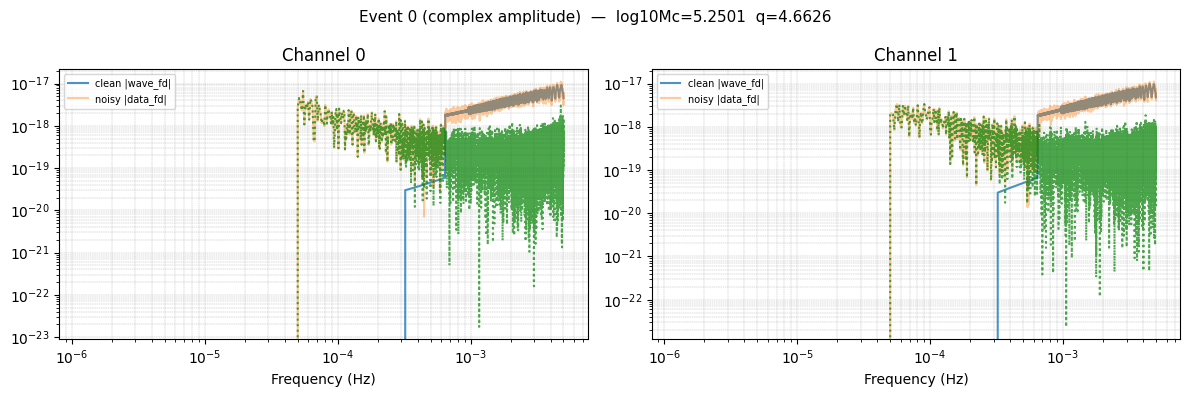

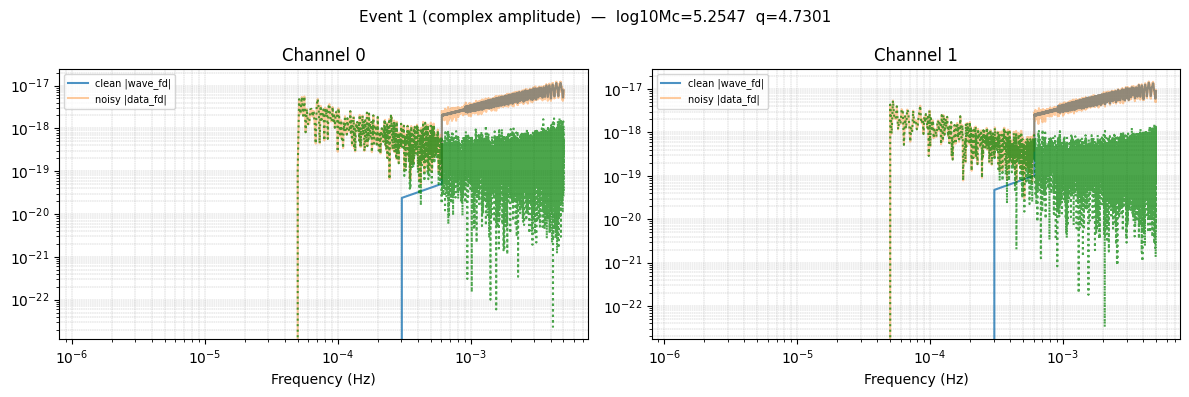

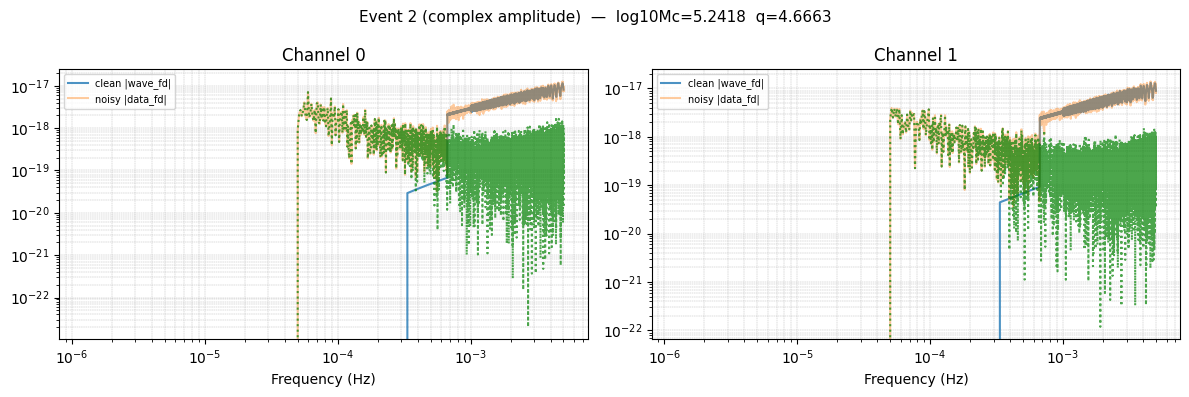

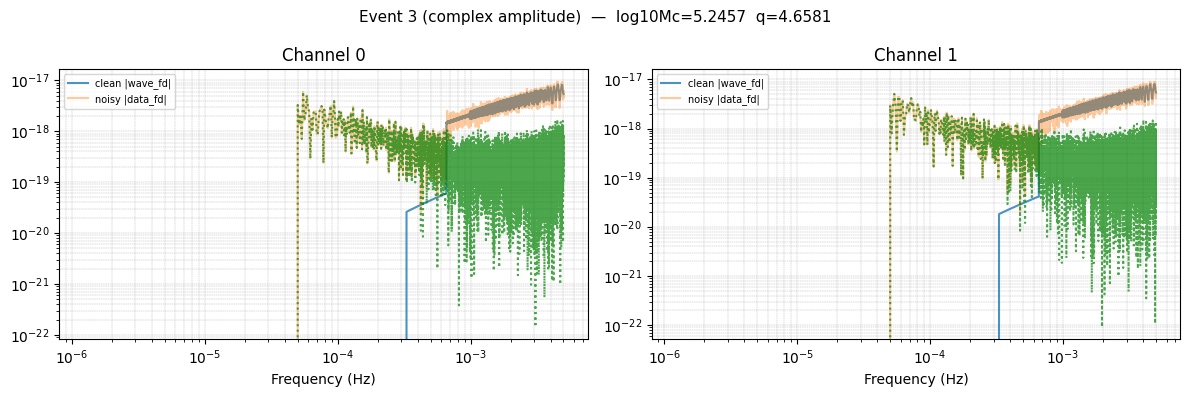

In [ ]:
# Also compare in the *complex* domain (amplitude)
# Reconstruct complex waveform from AE output through the full encode→decode pipeline
# (The AE works in normalised real space; here we compare amplitudes for intuition.)

amp_orig = torch.abs(wave_fd)
# Reconstruct complex waveform from the real representation output
# rec_real has shape (N, 2*n_ch, n_freqs) where real and imag are interleaved
rec_complex = ae._real_to_complex(rec_real.to(device)).cpu()
amp_rec = torch.abs(rec_complex)
amp_data = torch.abs(data_fd)

for j in range(min(N_events_plot, n_samples)):
    fig, axes = plt.subplots(1, n_ch, figsize=(6 * n_ch, 4))
    if n_ch == 1:
        axes = [axes]
    for c in range(n_ch):
        ax = axes[c]
        ax.plot(freqs, amp_orig[j, c].numpy(), label='clean |wave_fd|', alpha=0.8)
        ax.plot(freqs, amp_data[j, c].numpy(), label='noisy |data_fd|', alpha=0.4)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Channel {c}')
        ax.legend(fontsize=7)
        ax.grid(True, which='both', ls='--', lw=0.3)
        # Compute and plot residual (difference between noisy and clean amplitudes)
        residual_amp = torch.abs(amp_data[j, c] - amp_orig[j, c]).numpy()
        ax.plot(freqs, residual_amp, color='green', label='|residual|', alpha=0.7, linestyle=':')
    p = params[j].numpy()
    fig.suptitle(f"Event {j} (complex amplitude)  —  log10Mc={p[0]:.4f}  q={p[1]:.4f}", fontsize=11)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 4 — Distribution of relative errors

In [13]:
# Relative error in the normalised-real space (the space the AE loss is defined in)
residual_norm = (rec_norm - clean_norm).reshape(n_samples, -1)
clean_norm_flat = clean_norm.reshape(n_samples, -1)

abs_err = torch.linalg.norm(residual_norm, dim=1)
clean_norms = torch.linalg.norm(clean_norm_flat, dim=1)
rel_err = (abs_err / clean_norms).numpy()

mean_rel_err = float(np.mean(rel_err))
median_rel_err = float(np.median(rel_err))
std_rel_err = float(np.std(rel_err))
max_rel_err = float(np.max(rel_err))

print(f"Relative error statistics (normalised-real space, {n_samples} samples):")
print(f"  mean   = {mean_rel_err:.4e}")
print(f"  median = {median_rel_err:.4e}")
print(f"  std    = {std_rel_err:.4e}")
print(f"  max    = {max_rel_err:.4e}")

Relative error statistics (normalised-real space, 2000 samples):
  mean   = 6.3362e-02
  median = 5.9423e-02
  std    = 1.9007e-02
  max    = 1.1497e-01


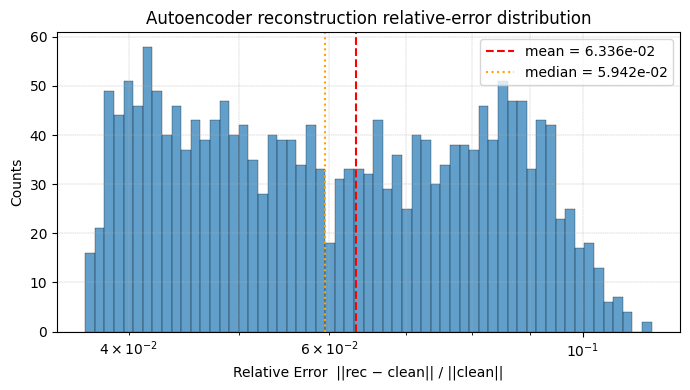

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bins = np.logspace(np.log10(rel_err.min() + 1e-20), np.log10(rel_err.max() + 1e-5), 60)
ax.hist(rel_err, bins=bins, alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(mean_rel_err, color='red', linestyle='--', lw=1.5,
           label=f'mean = {mean_rel_err:.3e}')
ax.axvline(median_rel_err, color='orange', linestyle=':', lw=1.5,
           label=f'median = {median_rel_err:.3e}')
ax.set_xscale('log')
ax.set_xlabel('Relative Error  ||rec − clean|| / ||clean||')
ax.set_ylabel('Counts')
ax.set_title('Autoencoder reconstruction relative-error distribution')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_relative_error_histogram.png'), dpi=200)
plt.show()
plt.close(fig)

## 5 — Eigenvalues of covariance matrices

Compare the spectral structure of:
- **data** (noisy, `wave_fd + noise_fd`)
- **waveform** (clean, `wave_fd`)
- **bottleneck** (compressed representation)

In [15]:
def top_eigenvalues(X: torch.Tensor, label: str, max_eigs: int = 200):
    """Compute top eigenvalues of the covariance of X (N, D).
    Uses SVD on the centred data matrix for numerical stability."""
    X = X.float()
    X_c = X - X.mean(dim=0, keepdim=True)
    # If D > N use X X^T trick, otherwise X^T X
    N, D = X_c.shape
    if D > N:
        gram = X_c @ X_c.T / (N - 1)
        eigs = torch.linalg.eigvalsh(gram)
    else:
        cov = X_c.T @ X_c / (N - 1)
        eigs = torch.linalg.eigvalsh(cov)
    eigs = eigs.flip(0)[:max_eigs].numpy()
    print(f"[{label}] shape={tuple(X.shape)}, top-5 eigenvalues: {eigs[:5]}")
    return eigs

In [27]:
# Flatten to (N, D) matrices
# Use the real representation for data/waveform to match the AE's working space
data_real_flat   = ae._complex_to_real(data_fd).reshape(n_samples, -1)
wave_real_flat   = ae._complex_to_real(wave_fd).reshape(n_samples, -1)
bottleneck_flat  = bottleneck  # already (N, D_bottleneck)

eigs_data   = top_eigenvalues(data_real_flat,  "noisy data")
eigs_wave   = top_eigenvalues(wave_real_flat,  "clean waveform")
eigs_bottle = top_eigenvalues(bottleneck_flat, "bottleneck")

[noisy data] shape=(2000, 16384), top-5 eigenvalues: [1.4597702e-32 1.3978675e-32 1.3253245e-32 1.3147560e-32 8.5556916e-33]
[clean waveform] shape=(2000, 16384), top-5 eigenvalues: [1.4596706e-32 1.3980617e-32 1.3252723e-32 1.3148610e-32 8.5541356e-33]
[bottleneck] shape=(2000, 512), top-5 eigenvalues: [0.30789167 0.205223   0.13279413 0.08916452 0.03903491]


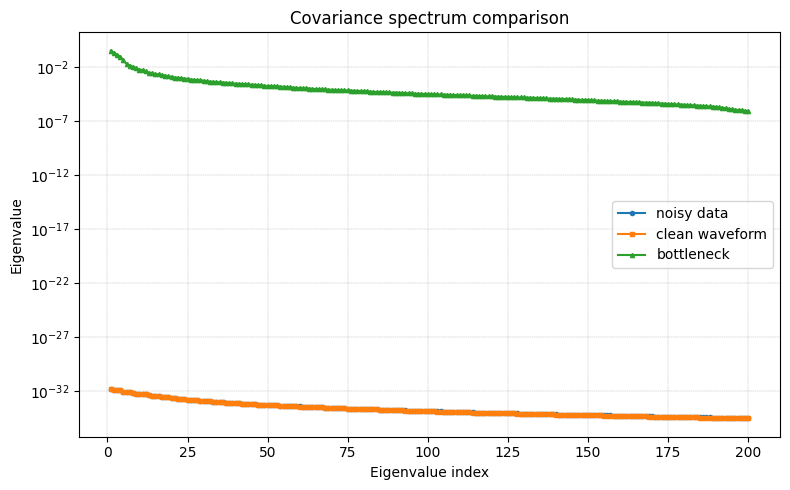

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(np.arange(1, len(eigs_data) + 1),   eigs_data,   'o-', ms=3, label='noisy data')
ax.plot(np.arange(1, len(eigs_wave) + 1),    eigs_wave,   's-', ms=3, label='clean waveform')
ax.plot(np.arange(1, len(eigs_bottle) + 1),  eigs_bottle, '^-', ms=3, label='bottleneck')

ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue')
ax.set_yscale('log')
ax.set_title('Covariance spectrum comparison')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_covariance_eigenvalues.png'), dpi=200)
plt.show()
plt.close(fig)

## 6 — Distance-vs-distance plots

1. Distance in bottleneck space  vs  distance between original waveforms
2. Distance between reconstructed waveforms  vs  distance between original waveforms

In [29]:
# Sub-sample to avoid huge distance matrices
N_dist = min(400, n_samples)

# Flatten representations
wave_flat = wave_real_flat[:N_dist]         # clean waveform (real repr)
rec_flat  = rec_real[:N_dist].reshape(N_dist, -1)  # reconstruction (denormalised real repr)
bn_flat   = bottleneck[:N_dist]              # bottleneck
par_sub   = params[:N_dist]

def pairwise_dist(X):
    """Upper-triangular pairwise Euclidean distances."""
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    D = torch.sqrt((diff ** 2).sum(dim=-1))
    mask = torch.triu(torch.ones(D.shape[0], D.shape[0], dtype=bool), diagonal=1)
    return D[mask].numpy()

d_wave = pairwise_dist(wave_flat)
d_rec  = pairwise_dist(rec_flat)
d_bn   = pairwise_dist(bn_flat)
d_par  = pairwise_dist(par_sub)

print(f"Number of pairwise distances: {len(d_wave)}")

Number of pairwise distances: 79800


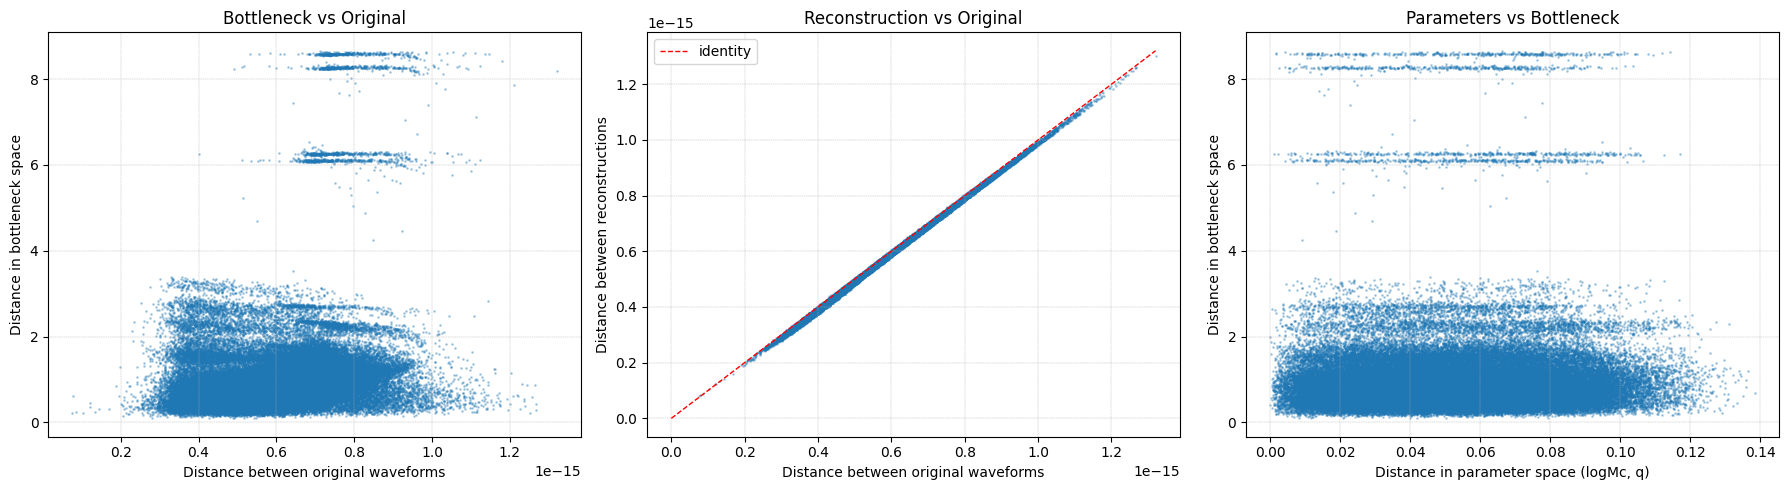

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) bottleneck dist vs waveform dist
ax = axes[0]
ax.scatter(d_wave, d_bn, s=1, alpha=0.3)
ax.set_xlabel('Distance between original waveforms')
ax.set_ylabel('Distance in bottleneck space')
ax.set_title('Bottleneck vs Original')
ax.grid(True, ls='--', lw=0.3)

# (2) reconstruction dist vs waveform dist
ax = axes[1]
ax.scatter(d_wave, d_rec, s=1, alpha=0.3)
lim = max(d_wave.max(), d_rec.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='identity')
ax.set_xlabel('Distance between original waveforms')
ax.set_ylabel('Distance between reconstructions')
ax.set_title('Reconstruction vs Original')
ax.legend()
ax.grid(True, ls='--', lw=0.3)

# (3) parameter dist vs bottleneck dist
ax = axes[2]
ax.scatter(d_par, d_bn, s=1, alpha=0.3)
ax.set_xlabel('Distance in parameter space (logMc, q)')
ax.set_ylabel('Distance in bottleneck space')
ax.set_title('Parameters vs Bottleneck')
ax.grid(True, ls='--', lw=0.3)

fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_distance_comparison.png'), dpi=200)
plt.show()
plt.close(fig)

## 7 — Sensitivity to single-parameter variation

Load datasets where one parameter is fixed and the other varies.  
For each, compute the relative distance to a fiducial waveform (middle of the prior)  
and overlay the mean reconstruction relative error as a horizontal reference line.

In [31]:
def load_variation_dataset(filename, ae_model, batch_size=100):
    """Load a fix-one-vary-other dataset and return waveforms, params, bottlenecks."""
    dm = MBHBDataModule(filename, batch_size=batch_size,
                        num_workers=2, cache_in_memory=False)
    dm.setup(stage="test")
    dl = dm.test_dataloader()

    waves, datas, bns, pars = [], [], [], []
    with torch.no_grad():
        for batch in dl:
            w = batch["wave_fd"].to(device)
            n = batch["noise_fd"].to(device)
            d = w + n
            p = batch["source_parameters"][:, :2].cpu()

            noisy_norm = ae_model.preprocess(d)
            bn, _skips = ae_model.encode(noisy_norm)

            waves.append(w.cpu())
            datas.append(d.cpu())
            bns.append(bn.reshape(bn.shape[0], -1).cpu())
            pars.append(p)

    return (torch.cat(waves), torch.cat(datas),
            torch.cat(bns), torch.cat(pars))

wave_fixq, data_fixq, bn_fixq, params_fixq = load_variation_dataset(fix_q_filename, ae)
wave_fixmc, data_fixmc, bn_fixmc, params_fixmc = load_variation_dataset(fix_mc_filename, ae)

print(f"fix-q  dataset: {wave_fixq.shape[0]} samples")
print(f"fix-mc dataset: {wave_fixmc.shape[0]} samples")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'miao', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# ── pick fiducial waveform (middle of the chirp-mass range in fix_q set) ──
mc_mid = params_fixq[:, 0].median()
idx_fid = torch.argmin(torch.abs(params_fixq[:, 0] - mc_mid)).item()
ref_wave = wave_fixq[idx_fid: idx_fid + 1]  # (1, C, F)
print(f"Fiducial event index={idx_fid}, "
      f"logMc={params_fixq[idx_fid, 0]:.6f}, q={params_fixq[idx_fid, 1]:.6f}")

In [ ]:
# Relative distance of each waveform to the fiducial
ref_norm = torch.linalg.norm(ref_wave.reshape(1, -1), dim=1)

def rel_dist_to_ref(waves, ref, ref_norm):
    diff = (waves - ref).reshape(waves.shape[0], -1)
    return (torch.linalg.norm(diff, dim=1) / ref_norm).numpy()

reldist_fixq  = rel_dist_to_ref(wave_fixq,  ref_wave, ref_norm)
reldist_fixmc = rel_dist_to_ref(wave_fixmc, ref_wave, ref_norm)

sort_fixq  = torch.argsort(params_fixq[:, 0])
sort_fixmc = torch.argsort(params_fixmc[:, 1])

In [ ]:
shared_ylim = (1e-5, max(reldist_fixq.max(), reldist_fixmc.max()) * 1.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fix q, vary chirp mass
ax = axes[0]
ax.plot(params_fixq[sort_fixq, 0].numpy(), reldist_fixq[sort_fixq], 'o-', ms=3)
ax.axhline(mean_rel_err, color='r', linestyle='--', lw=1.5,
           label=f'MeanRelErr = {mean_rel_err:.3e}')
ax.set_xlabel('log10 Mchirp')
ax.set_ylabel('Relative distance to fiducial')
ax.set_title('Fix mass ratio, vary chirp mass')
ax.set_yscale('log')
ax.set_ylim(shared_ylim)
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)

# Fix chirp mass, vary q
ax = axes[1]
ax.plot(params_fixmc[sort_fixmc, 1].numpy(), reldist_fixmc[sort_fixmc], 'o-', ms=3)
ax.axhline(mean_rel_err, color='r', linestyle='--', lw=1.5,
           label=f'MeanRelErr = {mean_rel_err:.3e}')
ax.set_xlabel('q (mass ratio)')
ax.set_ylabel('Relative distance to fiducial')
ax.set_title('Fix chirp mass, vary mass ratio')
ax.set_yscale('log')
ax.set_ylim(shared_ylim)
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)

fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_sensitivity_single_param.png'), dpi=200)
plt.show()
plt.close(fig)

In [ ]:
print("Done — all plots saved to:", plot_dir)